Objective:

The objective of this assignment is to implement and evaluate the K-Nearest Neighbours algorithm for classification using the given datasets

Dataset:

Need to Classify the animal type


In [43]:
# necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [44]:
# load the dataset
df=pd.read_csv('/content/Zoo.csv')

In [45]:
df.head()

,animal name,hair,feathers,eggs,milk,airborne,aquatic,predator,toothed,backbone,breathes,venomous,fins,legs,tail,domestic,catsize,type
0,aardvark,1,0,0,1,0,0,1,1,1,1,0,0,4,0,0,1,1
1,antelope,1,0,0,1,0,0,0,1,1,1,0,0,4,1,0,1,1
2,bass,0,0,1,0,0,1,1,1,1,0,0,1,0,1,0,0,4
3,bear,1,0,0,1,0,0,1,1,1,1,0,0,4,0,0,1,1
4,boar,1,0,0,1,0,0,1,1,1,1,0,0,4,1,0,1,1


In [46]:
df.shape

(101, 18)

In [47]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101 entries, 0 to 100
Data columns (total 18 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   animal name  101 non-null    object
 1   hair         101 non-null    int64 
 2   feathers     101 non-null    int64 
 3   eggs         101 non-null    int64 
 4   milk         101 non-null    int64 
 5   airborne     101 non-null    int64 
 6   aquatic      101 non-null    int64 
 7   predator     101 non-null    int64 
 8   toothed      101 non-null    int64 
 9   backbone     101 non-null    int64 
 10  breathes     101 non-null    int64 
 11  venomous     101 non-null    int64 
 12  fins         101 non-null    int64 
 13  legs         101 non-null    int64 
 14  tail         101 non-null    int64 
 15  domestic     101 non-null    int64 
 16  catsize      101 non-null    int64 
 17  type         101 non-null    int64 
dtypes: int64(17), object(1)
memory usage: 14.3+ KB


1. Analyse the data using the visualizations

Except legs and type every other features are binary.

<Axes: xlabel='type', ylabel='count'>

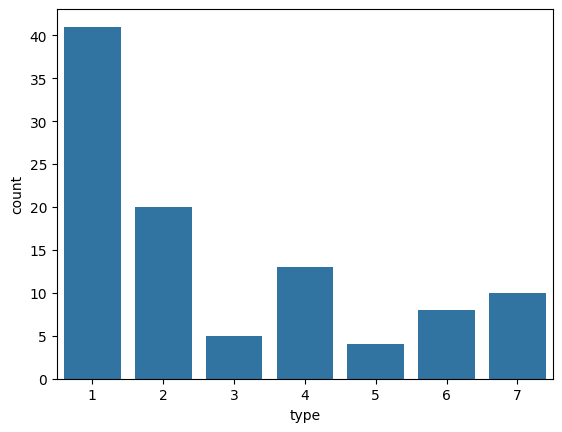

In [48]:
sns.countplot(x=df['type'])

<Axes: xlabel='legs', ylabel='count'>

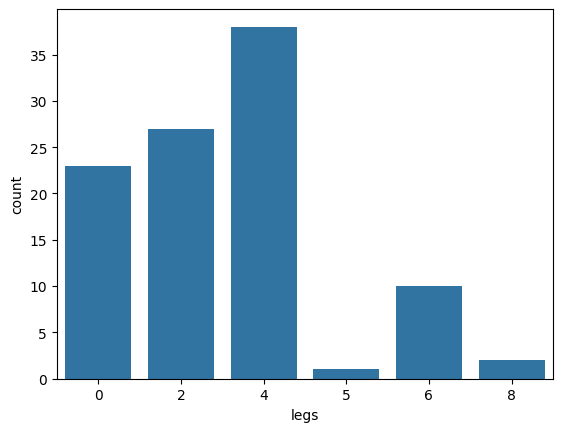

In [49]:
sns.countplot(x=df['legs'])

<Axes: >

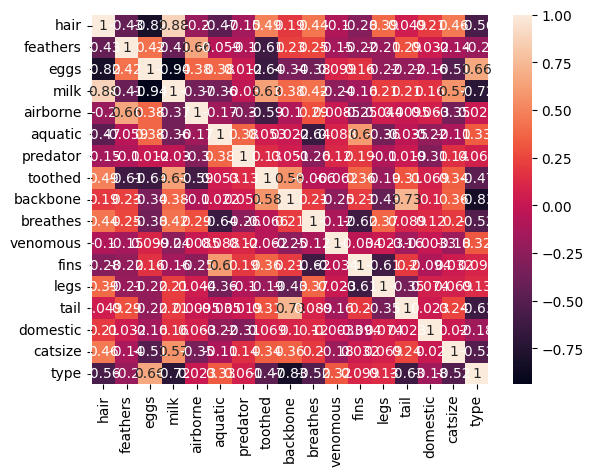

In [50]:
# correlation
corr=df.drop(columns='animal name').corr()
sns.heatmap(corr,annot=True)

2. Preprocess the data by handling missing values & Outliers, if any.

In [51]:
# checking missing values
df.isnull().sum()

,0
animal name,0
hair,0
feathers,0
eggs,0
milk,0
airborne,0
aquatic,0
predator,0
toothed,0
backbone,0


In [52]:
# duplicates
df.duplicated().any()

False

<Axes: >

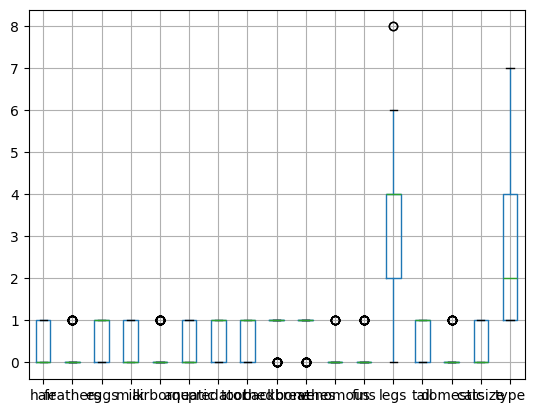

In [53]:
# outliers
df.boxplot()

Since most of the features are binary,outliers don't exist there.

But some of few features have but it cannot be replaced or removed because it is useful in finding the target.

In [54]:
# since target is categorical apply label encoder to label it
# labeling

from sklearn.preprocessing import LabelEncoder
lab_enc=LabelEncoder()
df['animal name']=lab_enc.fit_transform(df['animal name'])

In [55]:
# target is animal size
target=df['type']
target.head()

,type
0,1
1,1
2,4
3,1
4,1


In [56]:
features=df.drop(columns='type')
features.head()

,animal name,hair,feathers,eggs,milk,airborne,aquatic,predator,toothed,backbone,breathes,venomous,fins,legs,tail,domestic,catsize
0,0,1,0,0,1,0,0,1,1,1,1,0,0,4,0,0,1
1,1,1,0,0,1,0,0,0,1,1,1,0,0,4,1,0,1
2,2,0,0,1,0,0,1,1,1,1,0,0,1,0,1,0,0
3,3,1,0,0,1,0,0,1,1,1,1,0,0,4,0,0,1
4,4,1,0,0,1,0,0,1,1,1,1,0,0,4,1,0,1


In [57]:
# scaling
from sklearn.preprocessing import MinMaxScaler
min_max=MinMaxScaler()
features=pd.DataFrame(min_max.fit_transform(features),columns=features.columns)
features.head()


,animal name,hair,feathers,eggs,milk,airborne,aquatic,predator,toothed,backbone,breathes,venomous,fins,legs,tail,domestic,catsize
0,0.000000,1.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.5,0.0,0.0,1.0
1,0.010101,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.5,1.0,0.0,1.0
2,0.020202,0.0,0.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
3,0.030303,1.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.5,0.0,0.0,1.0
4,0.040404,1.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.5,1.0,0.0,1.0


3. Split the dataset into training and testing sets (80% training, 20% testing).

In [58]:
# splitting the data
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(features,target,train_size=0.8,random_state=100)

In [59]:
print(x_train.shape)
print(y_train.shape)
print(x_test.shape)
print(y_test.shape)

(80, 17)
(80,)
(21, 17)
(21,)


4. Implement the K-Nearest Neighbours algorithm using a machine learning library like scikit-learn On training dataset

In [60]:
from sklearn.neighbors import KNeighborsClassifier


In [61]:
knn=KNeighborsClassifier(n_neighbors=3)

In [62]:
knn.fit(x_train,y_train)

KNeighborsClassifier(n_neighbors=3)

In [63]:
y_pred=knn.predict(x_test)

5.Choose an appropriate distance metric and value for K

In [64]:
# Gridsearch for K value
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import GridSearchCV

In [65]:
params=dict(n_neighbors=range(1,100))
gridsearch=GridSearchCV(knn,params)
gridsearch.fit(x_train,y_train)
gridsearch.best_params_

{'n_neighbors': 1}

In [66]:
params=dict(metric=['euclidean','manhattan'])
gridsearch=GridSearchCV(knn,params)
gridsearch.fit(x_train,y_train)
gridsearch.best_params_

{'metric': 'euclidean'}

6.Evaluate the classifier's performance on the testing set using accuracy, precision, recall, and F1-score metrics.

In [67]:
# accuracy
from sklearn.metrics import accuracy_score

In [68]:
accuracy_score(y_test,y_pred)

0.9523809523809523

In [69]:
# precision,recall and F1-score
from sklearn.metrics import classification_report

In [70]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           1       1.00      1.00      1.00         8
           2       1.00      1.00      1.00         6
           3       1.00      1.00      1.00         1
           4       1.00      1.00      1.00         2
           5       1.00      1.00      1.00         2
           6       1.00      0.50      0.67         2
           7       0.00      0.00      0.00         0

    accuracy                           0.95        21
   macro avg       0.86      0.79      0.81        21
weighted avg       1.00      0.95      0.97        21



7. Visualize the decision boundaries of the classifier.

In [71]:
import numpy as np
from sklearn.decomposition import PCA

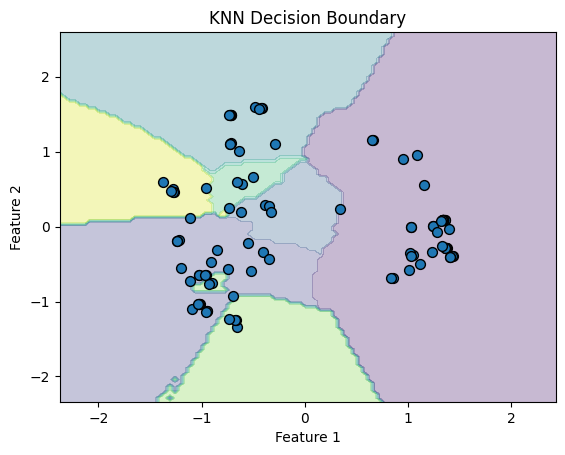

In [72]:
# pca
pca=PCA(n_components=2)
x_pca=pca.fit_transform(features)

x_min, x_max = x_pca[:, 0].min() - 1, x_pca[:, 0].max() + 1
y_min, y_max = x_pca[:, 1].min() - 1, x_pca[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100), np.linspace(y_min, y_max, 100))

knn1=KNeighborsClassifier()
knn1.fit(x_pca,target)
# Predict class for each point in the meshgrid
Z = knn1.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plot the decision boundary
plt.contourf(xx, yy, Z, alpha=0.3)
plt.scatter(x_pca[:, 0], x_pca[:, 1], edgecolors='k', marker='o', s=50, cmap=plt.cm.RdYlBu)

plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('KNN Decision Boundary')
plt.show()


Interview Questions:

In [73]:
#1. What are the key hyperparameters in KNN?
'''
The key parameters in KNN are
---- n_neighbors - describes the 'K' values.
---- metric - describes the distance methods such as euclidean,manhattan,hamming distance
'''

"\nThe key parameters in KNN are\n---- n_neighbors - describes the 'K' values.\n---- metric - describes the distance methods such as euclidean,manhattan,hamming distance\n"

In [74]:
#2. What distance metrics can be used in KNN?
'''
The distance metrics used in knn are
---- Euclidean Distance: The straight-line distance between two points in Euclidean space.
                          It is the most commonly used metric for KNN.

---- Manhattan Distance: It measures the distance between the two points along axes at right angles.

---- Hamming Distance: Used for categorical data.
                      It counts the number of positions at which the corresponding elements are different.

'''

'\nThe distance metrics used in knn are\n---- Euclidean Distance: The straight-line distance between two points in Euclidean space.\n                          It is the most commonly used metric for KNN.\n\n---- Manhattan Distance: It measures the distance between the two points along axes at right angles.\n\n---- Hamming Distance: Used for categorical data. \n                      It counts the number of positions at which the corresponding elements are different.\n                      \n'